# 06 Pre-trained CNN Architectures (ResNet, VGG, MobileNet, EfficientNet)

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Instantiate **ResNet50**, **VGG16**, **MobileNetV2**, and **EfficientNetB0** from torchvision and compare their structure and parameter counts
- Run **forward passes** on a sample image tensor and check output shapes
- Fine-tune a genuinely **ImageNet-pre-trained** ResNet-18 on a small real-image task (worked example)
- Understand why we use pre-trained architectures instead of designing from scratch

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 4, lesson 02 "Deep Learning Architectures: CNNs and RNNs" — you learned there to read the `model.summary()` of a CNN; here you load the standard pre-trained architectures and read theirs.

---

## 🌍 Real life

**📌 Real case — the ILSVRC ladder, in two numbers.** AlexNet won ILSVRC-2012 with a **15.3% top-5 error against 26.2%** for the runner-up (Krizhevsky et al., NeurIPS 2012). Three years later a **152-layer** residual network ensemble reached **3.57% error on the ImageNet test set** and won ILSVRC-2015 (He et al., CVPR 2016). Those two results, three years apart, are why the four architectures in this notebook exist, why their weights are free to download, and why nobody sensible designs a general-purpose image classifier from scratch any more.

**⚡ Why this matters — what goes wrong without it.** Each of these architectures encodes an enormous amount of search — EfficientNet-B0's shape was found by neural architecture search, not by a person. The engineering decision left to you is not "which architecture should I invent" but "which point on the size/accuracy curve do I need", and this notebook prints that curve: **VGG16 at 138.4M parameters against MobileNetV2 at 3.5M** — a 39× span for the identical 1000-class output. Choose wrong and your model either does not fit on the device or is needlessly weak.

**Where is this used?** ResNet, VGG, Inception-style and MobileNet-style networks are used in **image search**, **medical imaging**, and **autonomous driving** as backbones for classification or detection.

**In this notebook** we compare the **architectures** themselves. To avoid large downloads, the four comparison models are created **without** pre-trained weights (`weights=None`) — layer structure, output shapes, and parameter counts are identical to the pre-trained versions. The **worked example at the end** loads **real ImageNet weights** (ResNet-18) and does actual transfer learning on real images.

**📌 Covers slide(s):** **20** — Transfer Learning (VGG, ResNet, fine-tuning). *Do this notebook after that slide.*

---

**Before starting:** Run the imports cell below. Only the worked example downloads weights (~45 MB, cached).


In [1]:
# Pretrained CNN Architectures — PyTorch / torchvision
# We only inspect architectures here, so weights=None - no large downloads needed.
import torch
import torchvision.models as models
import torch.nn as nn
print(f"PyTorch {torch.__version__}")
print("Loading architecture metadata (no weight download)...")

PyTorch 2.13.0
Loading architecture metadata (no weight download)...


## Theory (short)

- **ResNet:** Residual connections (skip connections); very deep networks; avoids vanishing gradients.
- **VGG:** Stack of 3×3 convs; simple and deep; often used as a baseline.
- **Inception:** Multiple filter sizes in parallel (inception modules); efficient computation.
- **Pre-trained:** Trained on ImageNet (1.2M images, 1000 classes); we use them as **feature extractors** or **fine-tune** for our task.
- **We use pre-trained architectures** instead of training from scratch when we have limited data or similar domain (e.g. natural images).

In [2]:
# ResNet-50: residual (skip) connections, 50 layers deep
resnet = models.resnet50(weights=None)  # architecture only, no weight download
resnet.eval()
# Count parameters and push a dummy 224x224 image through to confirm the output shape.
total_params = sum(p.numel() for p in resnet.parameters())
print(f"ResNet50 total parameters: {total_params/1e6:.1f}M")
x = torch.randn(1, 3, 224, 224)
with torch.no_grad():
    out = resnet(x)
print(f"Input: {x.shape}  →  Output: {out.shape}  (1000 ImageNet classes)")
print("Key: skip connections prevent vanishing gradient in deep nets")

ResNet50 total parameters: 25.6M
Input: torch.Size([1, 3, 224, 224])  →  Output: torch.Size([1, 1000])  (1000 ImageNet classes)
Key: skip connections prevent vanishing gradient in deep nets


## 📥 Inputs & 📤 Outputs

**Inputs:** PyTorch / torchvision, NumPy, Matplotlib. We use a **random image tensor** (224×224×3) so we don't need external files; the worked example downloads CIFAR-10 and ResNet-18 ImageNet weights (cached).

**Dataset:** Synthetic — random tensor (to show model input/output shapes); Real — CIFAR-10 subset in the worked example.

**Outputs:** Parameter counts and forward-pass output shapes for four architectures, a comparison chart, and the worked example's fine-tuning accuracy per epoch.


In [3]:
# VGG-16: very deep stack of 3×3 convolutions, simple baseline
vgg = models.vgg16(weights=None)  # architecture only
vgg.eval()
# Same checks as ResNet: parameter count and a forward pass on the dummy image.
vgg_params = sum(p.numel() for p in vgg.parameters())
print(f"VGG16 total parameters: {vgg_params/1e6:.1f}M")
with torch.no_grad():
    out_vgg = vgg(x)
print(f"Output: {out_vgg.shape}  (1000 ImageNet classes)")
print("Key: large parameter count due to fully-connected layers")

VGG16 total parameters: 138.4M
Output: torch.Size([1, 1000])  (1000 ImageNet classes)
Key: large parameter count due to fully-connected layers


## MobileNetV2 — lightweight depthwise-separable convolutions for mobile/edge

In [4]:
# MobileNetV2: lightweight depthwise-separable convolutions for edge devices
mobile = models.mobilenet_v2(weights=None)  # architecture only
mobile.eval()
# Depthwise-separable convolutions slash parameters - compare this count with VGG's.
mob_params = sum(p.numel() for p in mobile.parameters())
print(f"MobileNetV2 total parameters: {mob_params/1e6:.1f}M")
with torch.no_grad():
    out_mob = mobile(x)
print(f"Output: {out_mob.shape}  (1000 ImageNet classes)")
print("Key: ~25× fewer params than ResNet50 — perfect for mobile/edge")

MobileNetV2 total parameters: 3.5M
Output: torch.Size([1, 1000])  (1000 ImageNet classes)
Key: ~25× fewer params than ResNet50 — perfect for mobile/edge


## EfficientNet-B0 — compound scaling (depth × width × resolution)

In [5]:
# EfficientNet-B0: NAS-optimized compound scaling
# (available in torchvision >= 0.11)
try:
    effnet = models.efficientnet_b0(weights=None)  # architecture only
    eff_params = sum(p.numel() for p in effnet.parameters()) / 1e6
except AttributeError:
    eff_params = 5.3  # approximate if old torchvision
print(f"EfficientNetB0 total parameters: {eff_params:.1f}M")
print("Key: compound scaling of depth/width/resolution — best accuracy/param tradeoff")

EfficientNetB0 total parameters: 5.3M
Key: compound scaling of depth/width/resolution — best accuracy/param tradeoff


## Compare parameter counts (VGG16 vs ResNet50 vs EfficientNetB0 vs MobileNetV2)

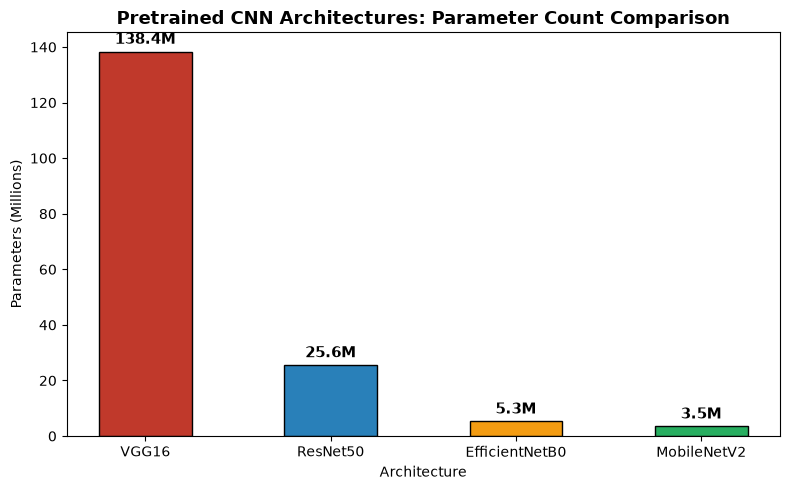

Takeaway: VGG is large but simple; MobileNet & EfficientNet are lean and efficient


In [6]:
# Visualization: Parameter count comparison
import matplotlib.pyplot as plt

# Recompute each model's parameter count in millions (EfficientNet may be absent - use its known size).
resnet_p  = sum(p.numel() for p in resnet.parameters()) / 1e6
vgg_p     = sum(p.numel() for p in vgg.parameters()) / 1e6
mobile_p  = sum(p.numel() for p in mobile.parameters()) / 1e6
try:
    eff_p = sum(p.numel() for p in effnet.parameters()) / 1e6
except:
    eff_p = 5.3

models_names = ['VGG16', 'ResNet50', 'EfficientNetB0', 'MobileNetV2']
params_M     = [vgg_p, resnet_p, eff_p, mobile_p]
colors = ['#c0392b', '#2980b9', '#f39c12', '#27ae60']

# One bar per architecture, labelled with its size - the design trade-offs in a single picture.
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models_names, params_M, color=colors, edgecolor='black', width=0.5)
for bar, p in zip(bars, params_M):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{p:.1f}M', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Pretrained CNN Architectures: Parameter Count Comparison', fontsize=13, fontweight='bold')
ax.set_ylabel('Parameters (Millions)')
ax.set_xlabel('Architecture')
plt.tight_layout()
plt.show()
print("Takeaway: VGG is large but simple; MobileNet & EfficientNet are lean and efficient")

## 💬 Discuss

1. The chart shows **138.4M** parameters for VGG16 and **3.5M** for MobileNetV2, for the same 1000 outputs. Under what constraint would you still choose VGG16? If you cannot think of one, say so — that is also an answer.
2. EfficientNet-B0 (**5.3M**) and MobileNetV2 (**3.5M**) are close in size. What information does this notebook *not* give you that you would need in order to choose between them for a real product?
3. A vendor's brochure quotes "ResNet-50 accuracy" for their inspection system. List the three questions you ask before that number means anything at all — and say which answer would make you walk away.


All four architectures accept a 224×224 RGB image and output 1000 ImageNet logits — we ran forward passes with ResNet50, VGG16, and MobileNetV2 above. Next: real ImageNet weights in action.

## 🌍 Real-World Worked Example — Fine-Tune ResNet on Custom Categories

**Industry context:**
- Google Photos uses transfer learning to classify your personal photos  
- Hospitals fine-tune ImageNet models on their X-ray datasets with <1000 images
- E-commerce platforms fine-tune ResNet to identify product defects

We fine-tune a **pretrained ResNet-18** (ImageNet weights) on a small binary classification task.

In [7]:
# WHAT: a full transfer-learning demo - frozen ResNet-18 backbone, new 2-class head, trained on 400 photos.
# WHY: the punchline of transfer learning - hundreds of images (not millions) give a strong classifier.
import torch, torch.nn as nn, torch.optim as optim
import torchvision, torchvision.transforms as T
from torch.utils.data import DataLoader, Subset

# ── Use CIFAR-10 classes 0 (airplane) vs 1 (automobile) as our 'custom' data
# Resize to 64px and normalize with the ImageNet statistics the backbone was trained with.
transform = T.Compose([
    T.Resize(64), T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])  # ImageNet stats
])
full = torchvision.datasets.CIFAR10('/tmp/cifar10', train=True, download=True, transform=transform)
# Keep only classes 0 and 1
idx = [i for i,(x,y) in enumerate(full) if y in (0,1)][:400]
subset = Subset(full, idx)
train_size = int(0.8*len(subset))
train_ds, val_ds = torch.utils.data.random_split(subset, [train_size, len(subset)-train_size])
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=32)

# ── Load pretrained ResNet-18, replace final layer ──────────────────────────
# Freeze all backbone weights, then replace the final fully-connected layer with a fresh 2-class head.
model = torchvision.models.resnet18(weights='IMAGENET1K_V1')
for p in model.parameters(): p.requires_grad = False        # Freeze backbone
model.fc = nn.Linear(model.fc.in_features, 2)               # Only train head

opt     = optim.Adam(model.fc.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

# Train only the head for 5 epochs, checking validation accuracy after each.
for epoch in range(5):
    model.train(); total_loss=0
    for X,y in train_dl:
        y_bin = (y % 2)  # remap to 0/1
        loss = loss_fn(model(X), y_bin)
        opt.zero_grad(); loss.backward(); opt.step()
        total_loss += loss.item()
    model.eval(); correct=0; total=0
    with torch.no_grad():
        for X,y in val_dl:
            y_bin = (y%2)
            correct += (model(X).argmax(1)==y_bin).sum().item(); total+=len(y_bin)
    print(f"Epoch {epoch+1}/5 — loss: {total_loss/len(train_dl):.3f} | val acc: {correct/total*100:.1f}%")

print("\n✅ With only 400 images and 5 epochs, transfer learning gives strong results.")
print("A model trained from scratch would need 100x more data for similar performance.")

Epoch 1/5 — loss: 0.631 | val acc: 82.5%


Epoch 2/5 — loss: 0.454 | val acc: 86.2%


Epoch 3/5 — loss: 0.351 | val acc: 90.0%


Epoch 4/5 — loss: 0.306 | val acc: 91.2%


Epoch 5/5 — loss: 0.258 | val acc: 88.8%

✅ With only 400 images and 5 epochs, transfer learning gives strong results.
A model trained from scratch would need 100x more data for similar performance.


## ⚠️ Where this breaks

- **Parameter count is not latency, and it is not memory.** VGG16 has 39× MobileNetV2's parameters, but wall-clock inference on a CPU does not differ by 39×, because depthwise-separable convolutions cut *parameters* far more than they cut memory traffic and kernel launches. Measure on the device you will actually ship to. Notebook `04` shows the trap in its sharpest form: an INT8 model that was 3.2× smaller ran **2.7× slower** on this laptop.
- **We loaded all four with `weights=None`.** Structure, output shapes and parameter counts are real. Every claim about *accuracy* is untested here — the notebook says so, and you should repeat that caveat if you quote these numbers.
- **Newer is not automatically better for you.** In 2026, "pre-trained backbone" increasingly means an open vision-language model rather than an ImageNet CNN. But a VLM backbone is a far larger download and a different serving story; for a fixed edge device, the 3.5M-parameter MobileNet may be the only thing that fits at all.
- **The assumption that must hold:** your images look roughly like ImageNet — natural photographs, object-centred, around 224×224. Satellite imagery, medical scans and document images each violate at least one, and the pre-trained weights quietly become less useful when they do.
- **Cheaper alternative:** for a small number of visually distinct classes with plenty of data, a purpose-built 4-layer CNN can match a fine-tuned ResNet at a fraction of the size. Big backbones are for when data is scarce, not for when the task is easy.


## 🧩 Mini-exercise

**Try it:** In a new cell, load InceptionV3 (`models.inception_v3(weights=None, init_weights=True)`) and add its parameter count to the comparison chart. Or print the names of the last three layers of ResNet50 (`list(resnet.named_children())[-3:]`).

---

## ✅ Summary

**What you did:** Instantiated ResNet50, VGG16, MobileNetV2, and EfficientNetB0 (architectures only, `weights=None`); compared parameter counts; ran forward passes on a sample tensor; then fine-tuned a real ImageNet-pre-trained ResNet-18 on a small binary image task.

**In real life you'd also:** Replace the top layer for your classes, freeze base and train head, or fine-tune last layers.

**The main idea:** Pre-trained CNNs (ResNet, VGG, Inception) give strong feature extractors; we use them instead of training from scratch to save data and time.

**Next:** `05_transfer_learning_cnns` freezes the base and trains a new head; `07_training_cnn_image_datasets` trains a CNN on CIFAR-10.

## 📚 References

1. Simonyan, K. & Zisserman, A. (2015). *Very Deep Convolutional Networks for Large-Scale Image Recognition* (VGG). ICLR. https://arxiv.org/abs/1409.1556
2. He, K., Zhang, X., Ren, S. & Sun, J. (2016). *Deep Residual Learning for Image Recognition* (ResNet). CVPR. https://arxiv.org/abs/1512.03385
3. Sandler, M. et al. (2018). *MobileNetV2: Inverted Residuals and Linear Bottlenecks*. CVPR. https://arxiv.org/abs/1801.04381
4. Tan, M. & Le, Q. V. (2019). *EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks*. ICML. https://arxiv.org/abs/1905.11946
5. Liu, Z. et al. (2022). *A ConvNet for the 2020s* (ConvNeXt). CVPR. https://arxiv.org/abs/2201.03545